# ED 2022 NHAMCS — Triage-Time Clinical Decision Support

Analysis for predicting hospital admission and surfacing under-triaged patients using **triage-time features only** (vitals, chief complaint, demographics, comorbidities).

In [4]:
%pip install pandas numpy matplotlib seaborn shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load
df = pd.read_csv('ED2022.csv', low_memory=False)

# 2. Replace missing codes (-9=blank, -8=unknown, -7=not applicable)
df.replace([-9, -8, -7], np.nan, inplace=True)

# Treat Doppler codes as missing for vitals
df.loc[df['PULSE'] == 998, 'PULSE'] = np.nan
df.loc[df['BPDIAS'] == 998, 'BPDIAS'] = np.nan

# 3. Fix TEMPF scale (stored as 984 → 98.4°F)
df['TEMP_F'] = df['TEMPF'] / 10.0

# 4. Engineer derived vitals
df['SHOCK_INDEX']    = df['PULSE'] / df['BPSYS']
df['PULSE_PRESSURE'] = df['BPSYS'] - df['BPDIAS']
df['MAP']            = df['BPDIAS'] + df['PULSE_PRESSURE'] / 3.0
df['SPO2_LOW']       = (df['POPCT'] < 95).astype('Int64')
df['TACHYCARDIA']    = (df['PULSE'] > 100).astype('Int64')
df['BRADYCARDIA']    = (df['PULSE'] < 60).astype('Int64')
df['FEVER']          = (df['TEMP_F'] > 100.4).astype('Int64')
df['HYPOTENSION']    = (df['BPSYS'] < 90).astype('Int64')
df['TACHYPNEA']      = (df['RESPR'] > 20).astype('Int64')

print('Shape:', df.shape)
print('ADMITHOS (admitted to this hospital):', df['ADMITHOS'].value_counts().to_dict())
print('Admission rate:', df['ADMITHOS'].mean().round(4))


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Shape: (16025, 923)
ADMITHOS (admitted to this hospital): {0: 13904, 1: 2121}
Admission rate: 0.1324


In [5]:
# 5. Map RFV (reason for visit) to clinical modules
RFV_MODULES = {
    'General Symptoms':         (10010, 10990),
    'Psychological/Mental':     (11000, 11990),
    'Neurological':             (12000, 12590),
    'Eyes/Ears':                (13000, 13990),
    'Respiratory':              (14000, 14990),
    'Digestive/GI':             (15000, 16390),
    'Genitourinary':            (16400, 18290),
    'Skin':                     (18300, 18990),
    'Musculoskeletal':          (19000, 19990),
    'Infectious/Parasitic':     (20010, 20990),
    'Neoplasms':                (21000, 21990),
    'Endocrine/Metabolic':      (22000, 22490),
    'Cardiovascular':           (25000, 25990),
    'Injury/Trauma/Poisoning':  (50010, 59250),
    'Administrative':           (71000, 71400),
}

def map_rfv_to_module(code):
    if pd.isna(code) or code < 0:
        return 'Unknown'
    for name, (lo, hi) in RFV_MODULES.items():
        if lo <= code <= hi:
            return name
    return 'Other'

df['RFV1_MODULE'] = df['RFV1'].apply(map_rfv_to_module)
df['RFV1_MODULE'].value_counts()

RFV1_MODULE
General Symptoms           2532
Digestive/GI               2367
Injury/Trauma/Poisoning    2149
Respiratory                1996
Musculoskeletal            1875
Other                      1770
Neurological                990
Psychological/Mental        649
Genitourinary               629
Eyes/Ears                   416
Skin                        309
Cardiovascular              183
Administrative               45
Endocrine/Metabolic          42
Infectious/Parasitic         37
Unknown                      25
Neoplasms                    11
Name: count, dtype: int64

In [6]:
# 6. Triage-time feature set (NO labs, NO diagnoses — available in first ~5 min)
TARGET = 'ADMITHOS'

TRIAGE_FEATURES = [
    'TEMP_F', 'PULSE', 'RESPR', 'BPSYS', 'BPDIAS', 'POPCT', 'PAINSCALE',
    'SHOCK_INDEX', 'PULSE_PRESSURE', 'MAP', 'SPO2_LOW', 'TACHYCARDIA',
    'BRADYCARDIA', 'FEVER', 'HYPOTENSION', 'TACHYPNEA',
    'IMMEDR', 'ARREMS', 'SEEN72', 'INJURY',
    'AGE', 'SEX', 'RACERETH', 'RESIDNCE', 'PAYTYPER',
    'TOTCHRON', 'CHF', 'COPD', 'CAD', 'CANCER', 'CKD',
    'DIABTYP2', 'HTN', 'OBESITY', 'ASTHMA', 'DEPRN', 'ETOHAB', 'HYPLIPID', 'OSA',
]

---
## 1. Core crosstab: Chief complaint × triage level → admission rate

**Goal:** Find which chief complaint modules, at *semi-urgent (4)* and *non-urgent (5)* triage, have the highest unexpected admission rates — i.e. "missed" / under-triaged patients.

In [7]:
# Restrict to valid ESI levels 1–5 (exclude 7 = no triage system)
valid = df['IMMEDR'].between(1, 5)
ct = df.loc[valid].groupby(['RFV1_MODULE', 'IMMEDR'])[TARGET].agg(['mean', 'count']).reset_index()
ct.columns = ['RFV1_MODULE', 'IMMEDR', 'admission_rate', 'n']

# Focus on semi-urgent (4) and non-urgent (5)
semi_non = ct[ct['IMMEDR'].isin([4, 5])]
semi_non = semi_non[semi_non['n'] >= 30]  # minimum sample
semi_non = semi_non.sort_values('admission_rate', ascending=False)

print('Top RFV modules by admission rate at semi-urgent / non-urgent triage (n≥30):')
display(semi_non.head(20))

Top RFV modules by admission rate at semi-urgent / non-urgent triage (n≥30):


,RFV1_MODULE,IMMEDR,admission_rate,n
13,Digestive/GI,5.0,0.060606,33
12,Digestive/GI,4.0,0.055336,253
59,Other,5.0,0.042857,70
63,Psychological/Mental,4.0,0.040816,49
53,Neurological,4.0,0.036697,109
58,Other,4.0,0.030303,264
69,Respiratory,5.0,0.028571,35
26,General Symptoms,4.0,0.020761,289
40,Injury/Trauma/Poisoning,4.0,0.015595,513
45,Musculoskeletal,4.0,0.015228,591


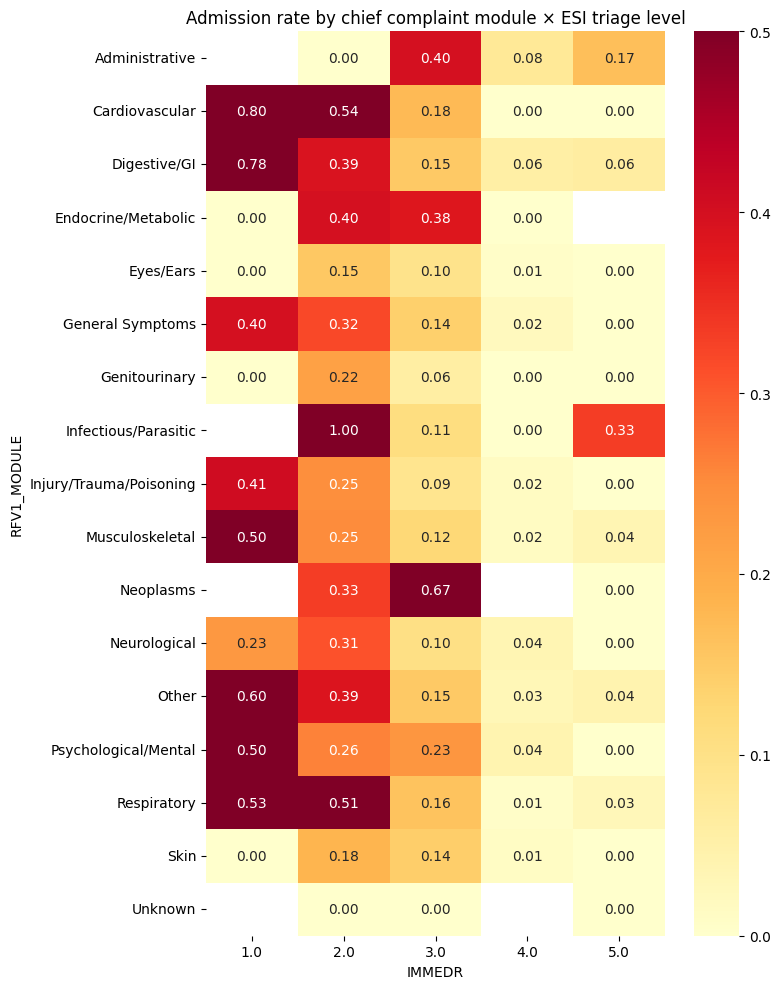

In [8]:
# Heatmap: admission rate by RFV module × triage level (ESI 1–5)
pivot = df.loc[valid].pivot_table(
    values=TARGET, index='RFV1_MODULE', columns='IMMEDR',
    aggfunc='mean'
)
# Order columns 1–5, keep modules with enough data
pivot = pivot[[c for c in [1,2,3,4,5] if c in pivot.columns]]
pivot = pivot.loc[pivot.notna().any(axis=1)]
plt.figure(figsize=(8, 10))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=0.5)
plt.title('Admission rate by chief complaint module × ESI triage level')
plt.tight_layout()
plt.show()

---
## 2. Vital sign profiling of under-triaged patients

**Goal:** Among patients who were admitted, compare vital sign patterns at triage:
- **Under-triaged:** ESI 4 or 5 (semi-/non-urgent) but admitted
- **Correctly triaged:** ESI 1, 2, or 3 and admitted

In [9]:
admitted = df[df[TARGET] == 1].copy()
admitted = admitted[admitted['IMMEDR'].between(1, 5)]
admitted['under_triaged'] = admitted['IMMEDR'].isin([4, 5])

vital_cols = ['SHOCK_INDEX', 'PULSE_PRESSURE', 'SPO2_LOW', 'TACHYCARDIA', 'FEVER', 'HYPOTENSION', 'TACHYPNEA', 'POPCT', 'BPSYS', 'PULSE', 'TEMP_F', 'RESPR']
summary = admitted.groupby('under_triaged')[vital_cols].agg(['mean', 'median', 'std', 'count'])
summary.T

under_triaged               False       True 
SHOCK_INDEX    mean      0.705213    0.654659
               median    0.657519    0.591135
               std       0.250627    0.208292
               count         1278          60
PULSE_PRESSURE mean     57.811189   59.822581
               median        55.0        58.5
               std      21.955297   17.994101
               count         1287          62
SPO2_LOW       mean      0.162142    0.045455
               median         0.0         0.0
               std        0.36872    0.209895
               count         1326          66
TACHYCARDIA    mean      0.311463    0.227273
               median         0.0         0.0
               std       0.463266    0.422282
               count         1326          66
FEVER          mean      0.033183    0.030303
               median         0.0         0.0
               std        0.17918    0.172733
               count         1326          66
HYPOTENSION    mean       0.03092         0.0
               median         0.0         0.0
               std       0.173166         0.0
               count         1326          66
TACHYPNEA      mean      0.220211    0.242424
               median         0.0         0.0
               std       0.414545    0.431834
               count         1326          66
POPCT          mean     96.486217   97.045455
               median        98.0        98.0
               std       6.181808     4.40081
               count         1306          66
BPSYS          mean    136.332298  136.709677
               median       135.0       133.0
               std      28.188203   22.577653
               count         1288          62
PULSE          mean     92.153787   88.515625
               median        89.0        84.0
               std      22.617095   20.165185
               count         1307          64
TEMP_F         mean      98.22943   98.385937
               median        98.1       98.25
               std       1.029157    0.915279
               count         1264          64
RESPR          mean      19.90054   20.287879
               median        18.0        18.0
               std       6.233507    5.049799
               count         1297          66

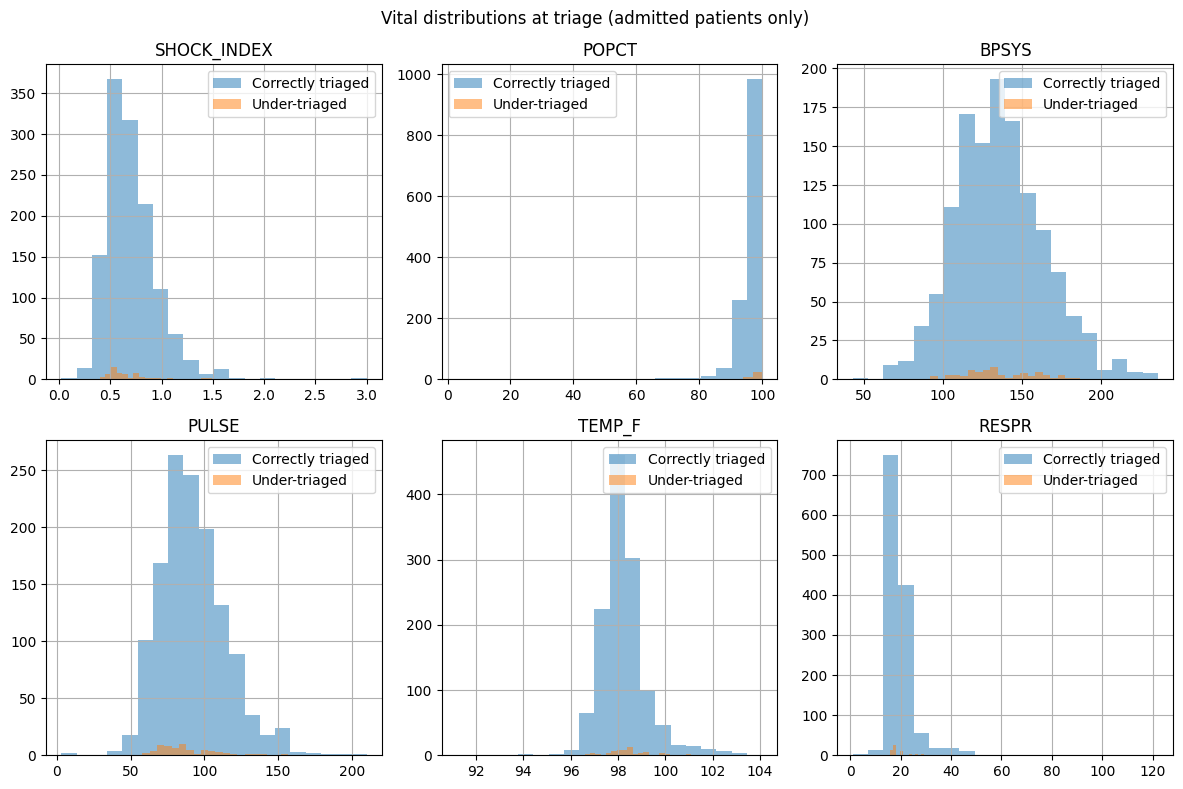

In [10]:
# Compare distributions: under-triaged vs correctly-triaged (admitted only)
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()
for i, col in enumerate(['SHOCK_INDEX', 'POPCT', 'BPSYS', 'PULSE', 'TEMP_F', 'RESPR']):
    for label, sub in admitted.groupby('under_triaged'):
        sub[col].dropna().hist(ax=axes[i], alpha=0.5, label=f"{'Under-triaged' if label else 'Correctly triaged'}", bins=20)
    axes[i].set_title(col)
    axes[i].legend()
plt.suptitle('Vital distributions at triage (admitted patients only)')
plt.tight_layout()
plt.show()

---
## 3. Triage-time admission prediction model

**Goal:** Using **only triage-time features**, predict `ADMITHOS`. Compare Gradient Boosting (with SHAP) vs Logistic Regression. Evaluate AUC, calibration, and subgroup performance (age, sex, race).

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
from sklearn.calibration import calibration_curve

# Model-ready dataframe: numeric triage features + one-hot RFV module
use_cols = [c for c in TRIAGE_FEATURES if c in df.columns]
X_num = df[use_cols].copy()
X_cat = pd.get_dummies(df['RFV1_MODULE'], prefix='RFV', drop_first=False)
X = pd.concat([X_num.reset_index(drop=True), X_cat.reset_index(drop=True)], axis=1)
y = df[TARGET].astype(float)

# Drop rows with missing target or all-NaN feature row (simple approach: dropna on X columns that matter most)
X['_target'] = y.values
ml_df = X.dropna(subset=['_target']).copy()
y_clean = ml_df['_target']
X_clean = ml_df.drop(columns=['_target'])
# Drop rows with any remaining NaN for this exercise (or use SimpleImputer)
X_clean = X_clean.fillna(X_clean.median(numeric_only=True))
# Ensure all float64 (avoids SHAP TreeExplainer dtype errors from Int64/object)
X_clean = X_clean.astype(np.float64)
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.25, random_state=42, stratify=y_clean)
feature_names = list(X_clean.columns)

In [13]:
# Baseline: Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict_proba(X_test)[:, 1]
print('Logistic Regression AUC:', roc_auc_score(y_test, y_pred_lr))

# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict_proba(X_test)[:, 1]
print('Gradient Boosting AUC:', roc_auc_score(y_test, y_pred_gb))

print(classification_report(y_test, (y_pred_gb >= 0.5).astype(int), target_names=['Not admitted', 'Admitted']))

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression AUC: 0.7966480537874223
Gradient Boosting AUC: 0.8291549318703502
              precision    recall  f1-score   support

Not admitted       0.89      0.98      0.93      3477
    Admitted       0.61      0.23      0.33       530

    accuracy                           0.88      4007
   macro avg       0.75      0.60      0.63      4007
weighted avg       0.86      0.88      0.85      4007



### How to read the ROC curve

- **Axes:** X = False Positive Rate (how many non-admitted patients we wrongly flag as high-risk). Y = True Positive Rate (how many admitted patients we correctly flag as high-risk).
- **Diagonal dashed line:** Random guessing (AUC = 0.5). A useful model stays **above** this line.
- **AUC (area under the curve):** Single number for overall discrimination.
  - **0.5** = no better than chance.
  - **0.7–0.8** = acceptable for clinical support.
  - **0.8–0.9** = good.
  - **>0.9** = very strong (rare with triage-time-only data).
- **How to use it:** Pick an operating point (e.g. threshold 0.2): everyone with predicted probability ≥ 0.2 gets “high risk.” Higher threshold → fewer false alarms, more missed admissions. Lower threshold → more alerts, fewer misses. The curve shows the tradeoff at every threshold.

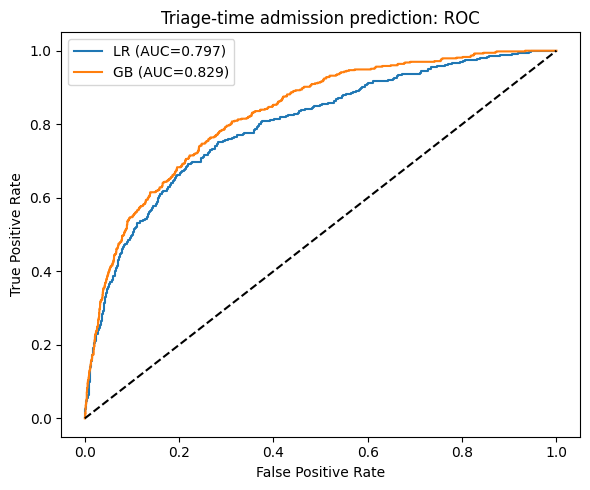

In [14]:
# ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_lr)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_pred_gb)
plt.figure(figsize=(6, 5))
plt.plot(fpr_lr, tpr_lr, label=f"LR (AUC={roc_auc_score(y_test, y_pred_lr):.3f})")
plt.plot(fpr_gb, tpr_gb, label=f"GB (AUC={roc_auc_score(y_test, y_pred_gb):.3f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.title('Triage-time admission prediction: ROC')
plt.tight_layout()
plt.show()

### How to read the calibration curve

- **Axes:** X = mean predicted probability in each bin. Y = actual fraction of patients who were admitted in that bin.
- **Diagonal dashed line:** Perfect calibration (e.g. when we predict 30% risk, 30% of those patients are actually admitted).
- **Above the diagonal:** Model is **under-confident** (predicts lower risk than reality — we may miss some high-risk patients).
- **Below the diagonal:** Model is **over-confident** (predicts higher risk than reality — more false alarms).
- **Why it matters:** A model can have good AUC but poor calibration. For decision support (e.g. “flag if risk > 20%”), we need probabilities we can trust; calibration tells you whether the numbers are believable.

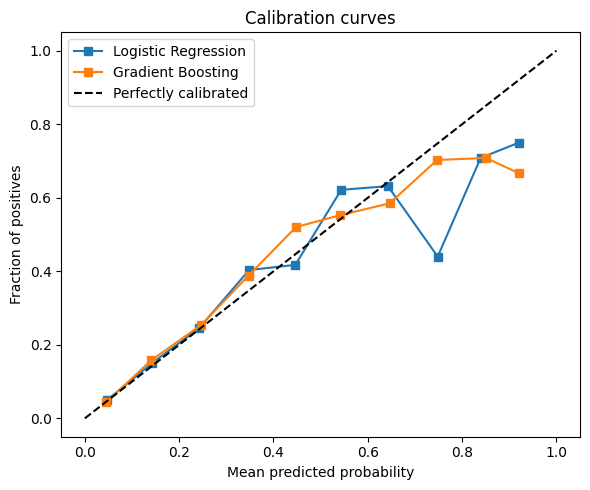

In [15]:
# Calibration
prob_true_lr, prob_pred_lr = calibration_curve(y_test, y_pred_lr, n_bins=10)
prob_true_gb, prob_pred_gb = calibration_curve(y_test, y_pred_gb, n_bins=10)
plt.figure(figsize=(6, 5))
plt.plot(prob_pred_lr, prob_true_lr, 's-', label='Logistic Regression')
plt.plot(prob_pred_gb, prob_true_gb, 's-', label='Gradient Boosting')
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.legend()
plt.title('Calibration curves')
plt.tight_layout()
plt.show()

In [16]:
# Subgroup performance: AUC by age group, sex, race
test_df = X_test.copy()
test_df['y'] = y_test.values
test_df['prob_gb'] = y_pred_gb
test_df['AGE_GROUP'] = pd.cut(test_df['AGE'], bins=[-1, 18, 45, 65, 100], labels=['0-18', '19-45', '46-65', '65+'])
test_df['SEX_LABEL'] = test_df['SEX'].map({1: 'Female', 2: 'Male'})
test_df['RACE_LABEL'] = test_df['RACERETH'].map({1: 'NH White', 2: 'NH Black', 3: 'Hispanic', 4: 'Other'})

for col, label in [('AGE_GROUP', 'Age'), ('SEX_LABEL', 'Sex'), ('RACE_LABEL', 'Race')]:
    aucs = test_df.groupby(col).apply(lambda g: roc_auc_score(g['y'], g['prob_gb']) if g['y'].nunique() > 1 else np.nan)
    print(f'{label}:', aucs.dropna().to_dict())

Age: {'0-18': 0.8113631049801262, '19-45': 0.7936965811965813, '46-65': 0.78525087887504, '65+': 0.7970945618547094}
Sex: {'Female': 0.8227671517671518, 'Male': 0.835141933574632}
Race: {'Hispanic': 0.7907212218806422, 'NH Black': 0.8285522098682387, 'NH White': 0.8358065343824838, 'Other': 0.8231792717086834}


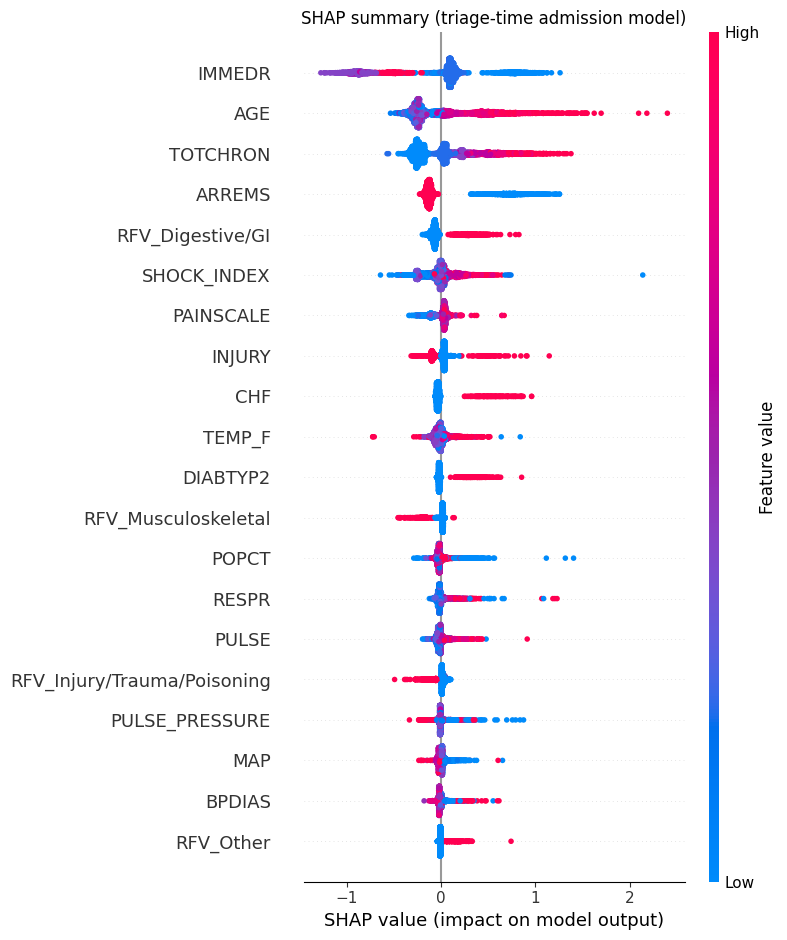

In [21]:
# SHAP feature importance (Gradient Boosting)
try:
    import shap
    # TreeExplainer requires float64 arrays (no object/Int64)
    X_train_f = np.asarray(X_train, dtype=np.float64)
    X_test_f = np.asarray(X_test, dtype=np.float64)
    explainer = shap.TreeExplainer(gb, X_train_f)
    shap_vals = explainer.shap_values(X_test_f)
    if isinstance(shap_vals, list):
        shap_vals = shap_vals[1]  # class 1 (admitted)
    shap.summary_plot(shap_vals, X_test_f, feature_names=feature_names, max_display=20, show=False)
    plt.title('SHAP summary (triage-time admission model)')
    plt.tight_layout()
    plt.show()
except ImportError:
    print("Install shap: pip install shap — skipping SHAP plot.")
    imp = pd.Series(gb.feature_importances_, index=feature_names).sort_values(ascending=False)
    print("Top 15 feature importances (Gradient Boosting):")
    print(imp.head(15))
except Exception as e:
    print("SHAP failed:", type(e).__name__, str(e)[:200])
    imp = pd.Series(gb.feature_importances_, index=feature_names).sort_values(ascending=False)
    print("Top 15 feature importances (Gradient Boosting):")
    print(imp.head(15))

### ADMIT destination (admitted patients only)

- `1` = Critical Care/ICU (key target), `2` = Stepdown, `3` = OR, `4` = Mental health/detox, `5` = Cath lab, `6` = Other bed

In [18]:
# ADMIT destination among admitted (1=ICU, 2=Stepdown, 3=OR, 4=Mental health, 5=Cath lab, 6=Other)
print('ADMIT (destination) among admitted patients:')
print(df.loc[df[TARGET] == 1, 'ADMIT'].value_counts().sort_index())

ADMIT (destination) among admitted patients:
ADMIT
1.0     347
2.0      81
3.0     153
4.0     105
5.0      43
6.0    1082
Name: count, dtype: int64


---
## Lab ordering and admission

**Goal:** Explore whether being chosen for lab tests (post-triage) is associated with admission. Lab orders are decided after initial assessment, so this is descriptive: do patients who get labs have higher admission rates? Do certain lab types (e.g. lactate, BNP) associate with admission?

In [ ]:
# Lab order columns (binary 0/1; after replace -9/-8/-7 they may have NaN → treat as 0 for "not ordered")
LAB_COLS = ['ABG', 'BAC', 'BMP', 'BNP', 'BUNCREAT', 'CARDENZ', 'CBC', 'CMP', 'BLOODCX', 'TRTCX', 'URINECX',
            'WOUNDCX', 'OTHCX', 'DDIMER', 'ELECTROL', 'GLUCOSE', 'LACTATE', 'LFT', 'PTTINR', 'OTHERBLD']
lab_present = [c for c in LAB_COLS if c in df.columns]
# Any lab ordered (1 if any of these is 1, else 0)
df['_lab_sum'] = df[lab_present].fillna(0).astype(float).sum(axis=1)
df['any_lab'] = (df['_lab_sum'] > 0).astype(int)
df['lab_count_bin'] = pd.cut(df['_lab_sum'], bins=[-0.1, 0, 2, 5, 100], labels=['0 labs', '1-2', '3-5', '6+'])

# Admission rate: any lab vs no labs
print('Admission rate by whether any lab was ordered:')
print(df.groupby('any_lab')[TARGET].agg(['mean', 'count']).rename(columns={'mean': 'admission_rate'}))
print()

# Admission rate by number of lab groups
print('Admission rate by number of labs ordered:')
print(df.groupby('lab_count_bin', observed=True)[TARGET].agg(['mean', 'count']).rename(columns={'mean': 'admission_rate'}))

In [ ]:
# Admission rate among patients who got each specific lab (vs overall)
# "Ordered" = value 1 (after replacing -9/-8/-7 with NaN, we use fillna(0) so 0 = not ordered)
lab_df = df[lab_present].fillna(0)
lab_rates = []
for c in lab_present:
    ordered = lab_df[c] == 1
    if ordered.sum() < 20:
        continue
    rate = df.loc[ordered, TARGET].mean()
    n = ordered.sum()
    lab_rates.append({'lab': c, 'admission_rate': rate, 'n_ordered': n})
lab_rates = pd.DataFrame(lab_rates).sort_values('admission_rate', ascending=False)
print('Admission rate when each lab was ordered (min 20 orders):')
display(lab_rates)

In [ ]:
# Visual: admission rate by any lab (yes/no) and by lab count bucket
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
# Any lab
ax1 = axes[0]
t = df.groupby('any_lab')[TARGET].agg(['mean', 'count'])
t.index = ['No labs', 'Any lab']
t['mean'].plot(kind='bar', ax=ax1, color=['C0', 'C1'])
ax1.set_ylabel('Admission rate')
ax1.set_title('Admission rate by whether any lab was ordered')
ax1.set_ylim(0, 0.3)
# By lab count
ax2 = axes[1]
t2 = df.groupby('lab_count_bin', observed=True)[TARGET].mean()
t2.plot(kind='bar', ax=ax2, color='steelblue')
ax2.set_ylabel('Admission rate')
ax2.set_title('Admission rate by number of labs ordered')
ax2.set_ylim(0, 0.35)
plt.tight_layout()
plt.show()

In [ ]:
# Bar chart: admission rate when each lab type was ordered
if len(lab_rates) > 0:
    ax = lab_rates.set_index('lab')['admission_rate'].plot(kind='barh', legend=False, figsize=(8, 6))
    ax.axvline(df[TARGET].mean(), color='gray', linestyle='--', label=f'Overall admission rate ({df[TARGET].mean():.2%})')
    ax.set_xlabel('Admission rate (among visits where this lab was ordered)')
    ax.set_ylabel('Lab type')
    ax.set_title('Admission rate by lab ordered (post-triage)')
    plt.legend()
    plt.tight_layout()
    plt.show()